# QuantWeather-BD 🌦️⚛️
## Quantum Machine Learning-Based Weather Forecasting for Bangladesh

**Dataset:** NASA POWER Daily Weather Data (1981–2026), Dhaka, Bangladesh  
**Model:** Hybrid Variational Quantum Circuit (VQC) + Classical Neural Network  
**Framework:** PennyLane + PyTorch  
**Target:** Next-day temperature prediction (T2M)

---

## ⚙️ Step 0: Install Dependencies

In [1]:
# Install required packages
!pip install pennylane pennylane-lightning -q
!pip install torch scikit-learn pandas numpy matplotlib seaborn joblib tqdm -q
print("✅ All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.3 MB/s eta 0:00:00
✅ All packages installed!


## 📦 Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
import joblib

plt.style.use('seaborn-v0_8')
np.random.seed(42)
torch.manual_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Libraries imported successfully.")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported successfully.
Using device: cuda
GPU: Tesla T4


## 🔗 Step 2: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


## 📂 Step 3: Load & Clean Dataset

In [4]:
# Dataset path (Google Drive)
dataset_path = '/content/drive/MyDrive/QuantWeather-BD/Dataset/bangladesh_weather_1981_2026.csv'

# Load CSV skipping 14 header rows
df = pd.read_csv(dataset_path, skiprows=14)

# Strip column names
df.columns = df.columns.str.strip()

# Create DATE column
df['DATE'] = pd.to_datetime(dict(year=df['YEAR'], month=df['MO'], day=df['DY']))

# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Sort by date
df = df.sort_values('DATE').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['DATE'].min()} → {df['DATE'].max()}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (16570, 10)
Date range: 1981-01-01 00:00:00 → 2026-05-14 00:00:00

Missing values:
YEAR           0
MO             0
DY             0
T2M            3
T2M_MAX        3
T2M_MIN        3
RH2M           3
PRECTOTCORR    3
WS2M           3
DATE           0
dtype: int64

First 5 rows:


,YEAR,MO,DY,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,DATE
0,1981,1,1,18.63,26.32,12.24,55.22,0.00,1.49,1981-01-01
1,1981,1,2,19.06,25.86,13.72,51.12,0.00,0.93,1981-01-02
2,1981,1,3,19.22,25.98,13.49,55.75,0.00,0.90,1981-01-03
3,1981,1,4,19.11,26.09,13.64,53.51,0.00,1.34,1981-01-04
4,1981,1,5,19.87,26.82,13.46,58.67,0.03,1.07,1981-01-05


## 📊 Step 4: Exploratory Data Analysis (EDA)

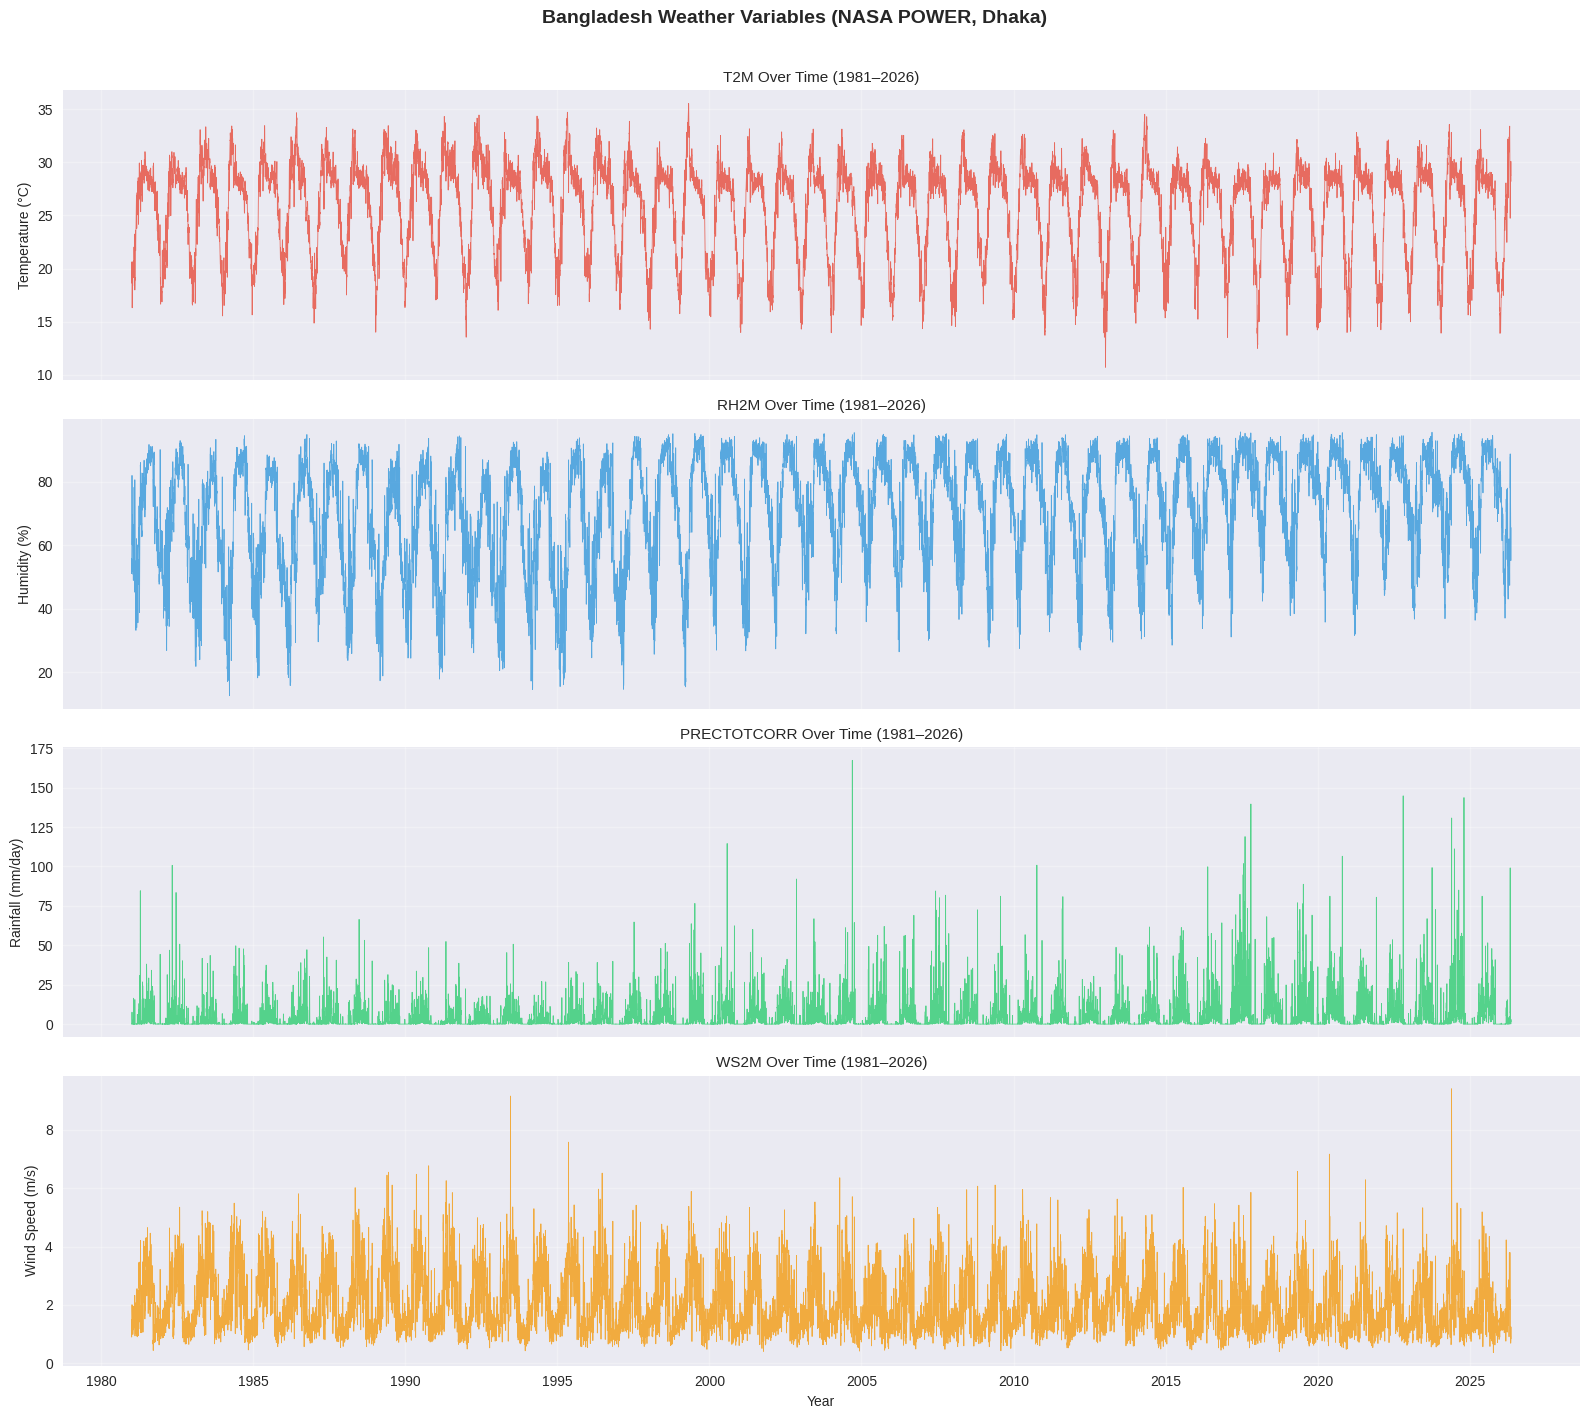

✅ Time series plot saved!


In [5]:
# Time series plots
weather_vars = ['T2M', 'RH2M', 'PRECTOTCORR', 'WS2M']
labels = ['Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)', 'Wind Speed (m/s)']

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (col, label, color) in enumerate(zip(weather_vars, labels, colors)):
    axes[i].plot(df['DATE'], df[col], linewidth=0.6, color=color, alpha=0.8)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].set_title(f'{col} Over Time (1981–2026)', fontsize=11)
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Year', fontsize=10)
plt.suptitle('Bangladesh Weather Variables (NASA POWER, Dhaka)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/QuantWeather-BD/eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Time series plot saved!")

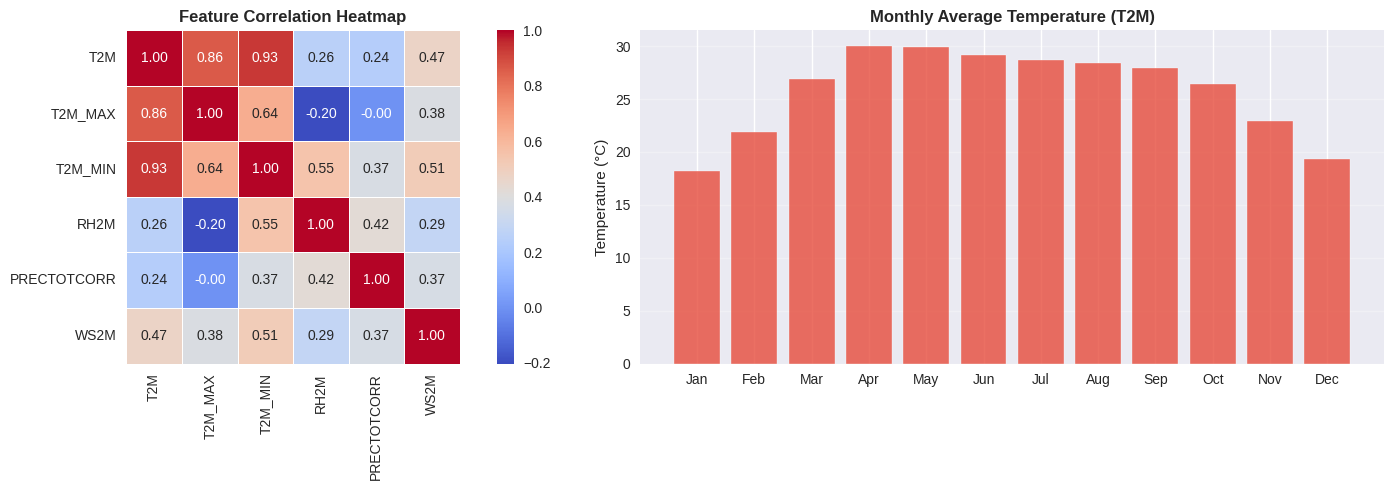

✅ Correlation plot saved!


In [6]:
# Correlation heatmap
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# Monthly average temperature
df['MONTH'] = df['DATE'].dt.month
monthly_avg = df.groupby('MONTH')['T2M'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, monthly_avg.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Monthly Average Temperature (T2M)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/QuantWeather-BD/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation plot saved!")

In [7]:
# Basic statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(df[corr_cols].describe().round(2))

DATASET STATISTICS
            T2M   T2M_MAX   T2M_MIN      RH2M  PRECTOTCORR      WS2M
count  16567.00  16567.00  16567.00  16567.00     16567.00  16567.00
mean      25.81     31.20     21.19     70.78         4.99      2.03
std        4.33      3.94      5.45     17.56         9.95      1.01
min       10.71     16.38      3.43     12.55         0.00      0.37
25%       22.55     28.76     16.44     58.23         0.00      1.25
50%       27.51     31.22     23.66     75.02         0.69      1.73
75%       28.84     33.34     25.84     85.99         5.85      2.70
max       35.52     44.47     29.42     95.77       167.28      9.41


## 🔧 Step 5: Feature Engineering

In [8]:
# Drop unnecessary columns
model_df = df.drop(columns=['YEAR', 'MO', 'DY', 'MONTH']).copy()

# Fill NaN with column mean
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].mean())

# Target: next day's T2M
model_df['TARGET_T2M_NEXT_DAY'] = model_df['T2M'].shift(-1)
model_df = model_df.dropna(subset=['TARGET_T2M_NEXT_DAY']).reset_index(drop=True)

# Features
feature_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
X = model_df[feature_cols].values
y = model_df['TARGET_T2M_NEXT_DAY'].values

# Normalize features to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20) - time order preserved
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print(f"Features used: {feature_cols}")
print(f"X_train shape: {X_train_t.shape}")
print(f"X_test shape:  {X_test_t.shape}")
print(f"y_train shape: {y_train_t.shape}")
print(f"y_test shape:  {y_test_t.shape}")

Features used: ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
X_train shape: torch.Size([13255, 6])
X_test shape:  torch.Size([3314, 6])
y_train shape: torch.Size([13255])
y_test shape:  torch.Size([3314])


## ⚛️ Step 6: QML Model (PennyLane + PyTorch Hybrid)

In [9]:
# Quantum device
n_qubits = 6
n_layers = 3
dev = qml.device('lightning.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {'weights': (n_layers, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridQMLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = quantum_layer
        self.fc1 = nn.Linear(n_qubits, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        q_out = self.quantum(x)
        out = self.relu(self.fc1(q_out))
        out = self.fc2(out)
        return out

model = HybridQMLModel()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params}")
print(f"Qubits: {n_qubits}, Layers: {n_layers}")
print("✅ Hybrid QML Model ready!")

HybridQMLModel(
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (fc1): Linear(in_features=6, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 183
Qubits: 6, Layers: 3
✅ Hybrid QML Model ready!


## 🏋️ Step 7: Training

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

epochs = 100
batch_size = 64
train_losses = []

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

print(f"Training on {len(X_train_t)} samples, batch size={batch_size}, epochs={epochs}")
print("-" * 60)

pbar = tqdm(range(1, epochs + 1), desc="Training", ncols=80)

for epoch in pbar:
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        preds = model(X_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    scheduler.step()
    pbar.set_postfix({'Loss': f'{avg_loss:.4f}'})

    if epoch % 10 == 0:
        tqdm.write(f'Epoch [{epoch:3d}/{epochs}] Loss: {avg_loss:.6f}')

print("-" * 60)
print(f"✅ Training complete! Final loss: {train_losses[-1]:.6f}")

Training on 13255 samples, batch size=64, epochs=100
------------------------------------------------------------


Training:  10%|█▌              | 10/100 [24:10<3:34:32, 143.03s/it, Loss=0.8365]

Epoch [ 10/100] Loss: 0.836533


Training:  20%|███▏            | 20/100 [48:07<3:12:35, 144.44s/it, Loss=0.7641]

Epoch [ 20/100] Loss: 0.764128


...

Epoch [ 80/100] Loss: 0.617146


Training:  90%|██████████████▍ | 90/100 [3:34:39<24:05, 144.60s/it, Loss=0.6159]

Epoch [ 90/100] Loss: 0.615862


Training: 100%|███████████████| 100/100 [3:58:19<00:00, 143.00s/it, Loss=0.6114]

Epoch [100/100] Loss: 0.611447
------------------------------------------------------------
✅ Training complete! Final loss: 0.611447


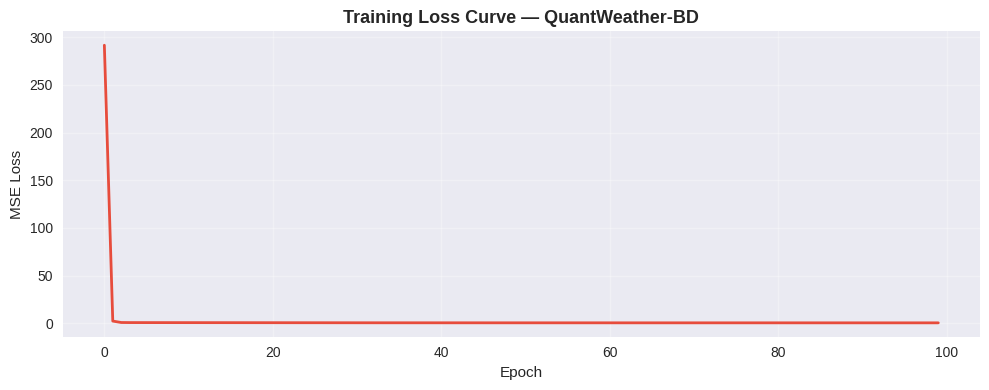

✅ Training loss plot saved!


In [11]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='#e74c3c', linewidth=2)
plt.title('Training Loss Curve — QuantWeather-BD', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/QuantWeather-BD/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training loss plot saved!")

## 📈 Step 8: Evaluation

In [12]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("   QML MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  : {mae:.4f} °C")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

   QML MODEL EVALUATION RESULTS
  MAE  : 0.5592 °C
  RMSE : 0.7435 °C
  R²   : 0.9721


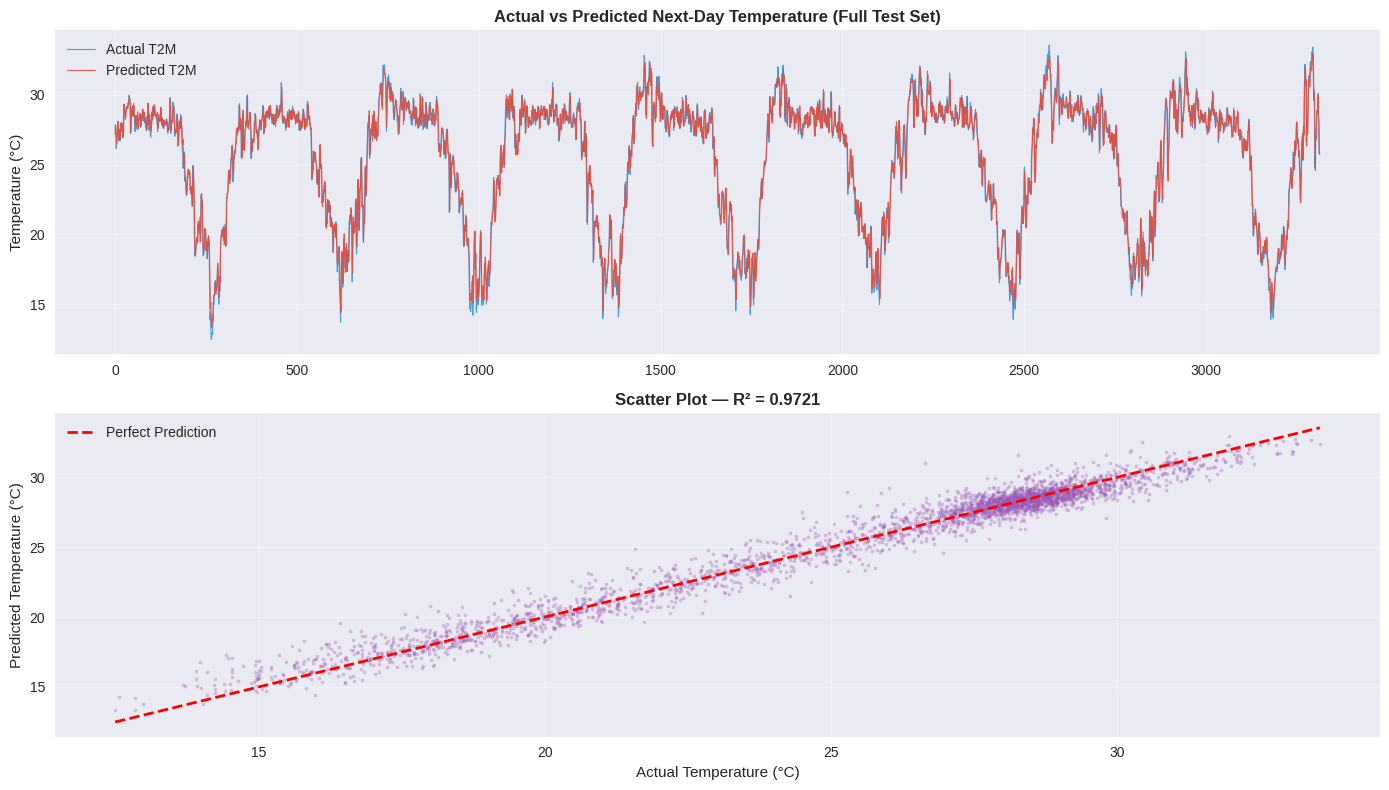

✅ Evaluation plots saved!


In [13]:
# Actual vs Predicted plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full comparison
axes[0].plot(y_test, label='Actual T2M', color='#3498db', linewidth=0.8, alpha=0.9)
axes[0].plot(y_pred, label='Predicted T2M', color='#e74c3c', linewidth=0.8, alpha=0.9)
axes[0].set_title('Actual vs Predicted Next-Day Temperature (Full Test Set)', fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(y_test, y_pred, alpha=0.3, color='#9b59b6', s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title(f'Scatter Plot — R² = {r2:.4f}', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/QuantWeather-BD/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved!")

## 🆚 Step 9: Baseline Comparison (Classical ML)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Results comparison
results = {
    'Model': ['Linear Regression', 'Random Forest', 'QML (Ours)'],
    'MAE':  [mean_absolute_error(y_test, y_pred_lr),
             mean_absolute_error(y_test, y_pred_rf),
             mae],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_rf)),
             rmse],
    'R²':   [r2_score(y_test, y_pred_lr),
             r2_score(y_test, y_pred_rf),
             r2]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("=" * 55)
print("         MODEL COMPARISON TABLE")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

         MODEL COMPARISON TABLE
            Model    MAE   RMSE     R²
Linear Regression 0.5681 0.7579 0.9710
    Random Forest 0.5755 0.7573 0.9710
       QML (Ours) 0.5592 0.7435 0.9721


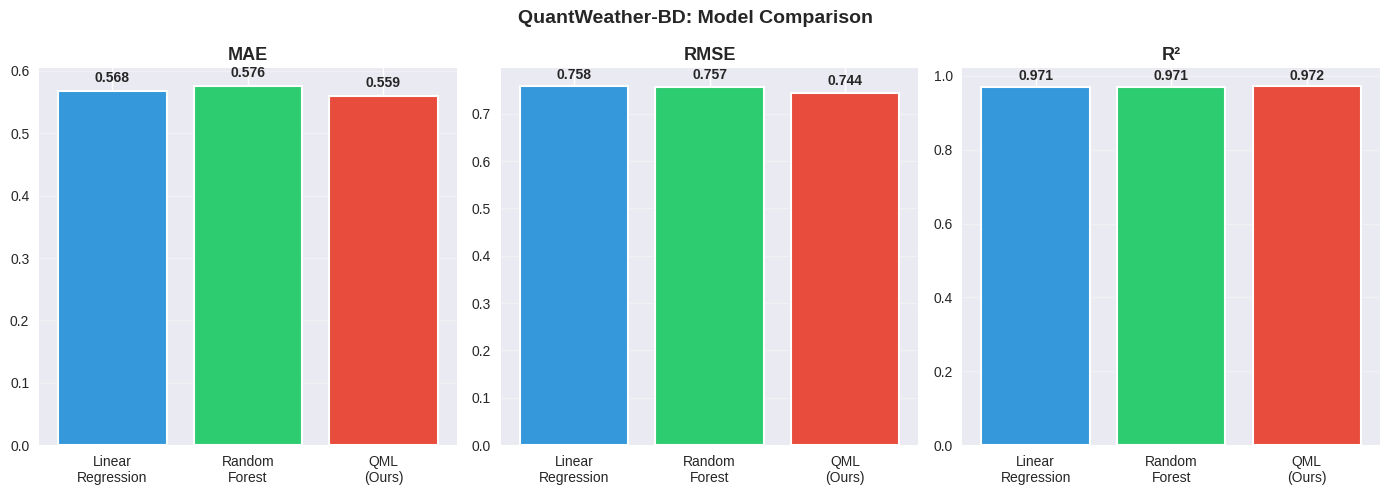

✅ Comparison chart saved!


In [15]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
models = ['Linear\nRegression', 'Random\nForest', 'QML\n(Ours)']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = results_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('QuantWeather-BD: Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/QuantWeather-BD/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

## 💾 Step 10: Save Model & Scaler

In [16]:
import os
save_dir = '/content/drive/MyDrive/QuantWeather-BD/'
os.makedirs(save_dir, exist_ok=True)

# Save QML model
model_path = save_dir + 'quantweather_bd_model.pth'
torch.save(model.state_dict(), model_path)

# Save scaler
scaler_path = save_dir + 'scaler.pkl'
joblib.dump(scaler, scaler_path)

# Save results
results_df.to_csv(save_dir + 'model_comparison_results.csv', index=False)

print(f"✅ Model saved     : {model_path}")
print(f"✅ Scaler saved    : {scaler_path}")
print(f"✅ Results saved   : {save_dir}model_comparison_results.csv")
print("\n🎉 All done! QuantWeather-BD training complete!")

✅ Model saved     : /content/drive/MyDrive/QuantWeather-BD/quantweather_bd_model.pth
✅ Scaler saved    : /content/drive/MyDrive/QuantWeather-BD/scaler.pkl
✅ Results saved   : /content/drive/MyDrive/QuantWeather-BD/model_comparison_results.csv

🎉 All done! QuantWeather-BD training complete!


## 📋 Step 11: Summary

In [17]:
print("="*60)
print("         QUANTWEATHER-BD — FINAL SUMMARY")
print("="*60)
print(f"  Dataset      : NASA POWER, Dhaka, Bangladesh")
print(f"  Date Range   : 1981-01-01 → 2026-05-14")
print(f"  Total Samples: {len(df)}")
print(f"  Features     : {feature_cols}")
print(f"  Target       : Next-day T2M (°C)")
print("-"*60)
print(f"  Qubits       : {n_qubits}")
print(f"  VQC Layers   : {n_layers}")
print(f"  Epochs       : {epochs}")
print(f"  Batch Size   : {batch_size}")
print("-"*60)
print(f"  QML MAE      : {mae:.4f} °C")
print(f"  QML RMSE     : {rmse:.4f} °C")
print(f"  QML R²       : {r2:.4f}")
print("="*60)

         QUANTWEATHER-BD — FINAL SUMMARY
  Dataset      : NASA POWER, Dhaka, Bangladesh
  Date Range   : 1981-01-01 → 2026-05-14
  Total Samples: 16570
  Features     : ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
  Target       : Next-day T2M (°C)
------------------------------------------------------------
  Qubits       : 6
  VQC Layers   : 3
  Epochs       : 100
  Batch Size   : 64
------------------------------------------------------------
  QML MAE      : 0.5592 °C
  QML RMSE     : 0.7435 °C
  QML R²       : 0.9721
